<a href="https://colab.research.google.com/github/jyotinayak321/IBM-ML-Training/blob/main/Agglomerative_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Column names:
Index(['CUSTID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

First 10 rows:
   CUSTID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  C10001    40.900749           0.818182      95.40              0.00   
1  C10002  3202.467416           0.909091       0.00              0.00   
2  C10003  2495.148862           1.000000     773.17            773.17   
3  C10004  1666.670542           0.636364    1499.00           1499.00   
4  C10005   817.714335           1.000000      16.00             16.00   
5  C10006  1809.828751           1.000000    1333.28              0.00   
6  C10007   627.260806           1.00000

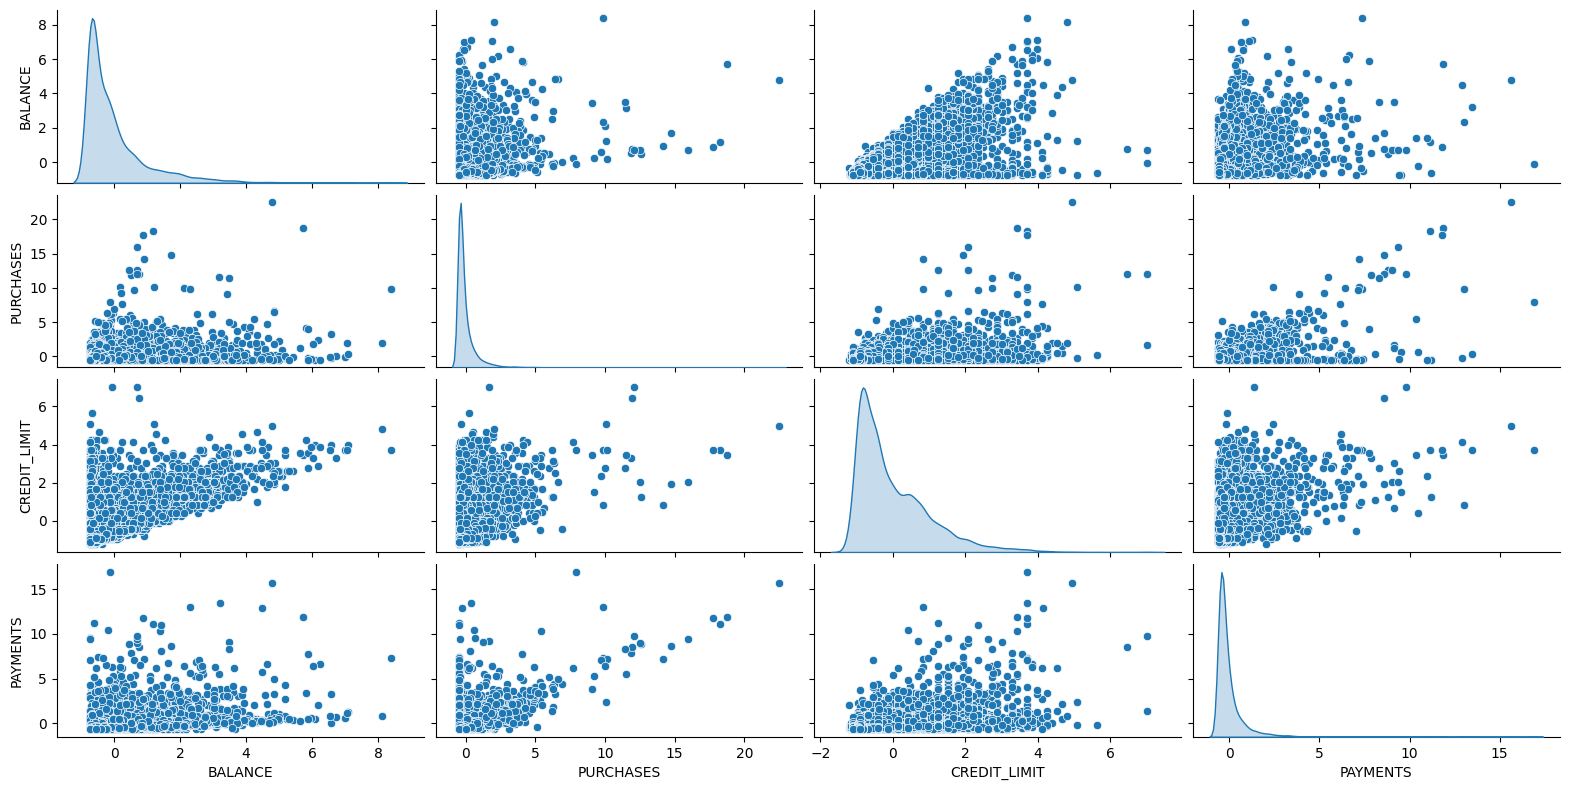


Cluster assignments:
       BALANCE  PURCHASES  CREDIT_LIMIT     PAYMENTS  labels
0    40.900749      95.40        1000.0   201.802084       1
1  3202.467416       0.00        7000.0  4103.032597       1
2  2495.148862     773.17        7500.0   622.066742       1
3  1666.670542    1499.00        7500.0     0.000000       1
4   817.714335      16.00        1200.0   678.334763       1
5  1809.828751    1333.28        1800.0  1400.057770       1
6   627.260806    7091.01       13500.0  6354.314328       1
7  1823.652743     436.20        2300.0   679.065082       1
8  1014.926473     861.49        7000.0   688.278568       1
9   152.225975    1281.60       11000.0  1164.770591       1

Cluster means:
            BALANCE     PURCHASES  CREDIT_LIMIT      PAYMENTS
labels                                                       
0       4847.010867  24777.369500  15825.000000  24722.098322
1       1554.187806    931.447735   4462.617363   1665.287901
2       8107.283094  42258.347500  18875.00

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import cophenet, dendrogram, linkage
from scipy.spatial.distance import pdist



#Read the CSV file


custData = pd.read_csv("Customer_Data.csv")

print("Column names:")
print(custData.columns)

print("\nFirst 10 rows:")
print(custData.head(10))

#Select the features for clustering


custDataAttr = custData[
    ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS']
]

print("\nSelected features:")
print(custDataAttr.head())



#Check for missing values


print("\nMissing values:")
print(custDataAttr.isnull().sum())



#Handle missing values


custDataAttr = custDataAttr.fillna(custDataAttr.mean())

print("\nMissing values after filling:")
print(custDataAttr.isnull().sum())



#Standardize the data


scaler = StandardScaler()

custDataScaled = scaler.fit_transform(custDataAttr)


# Convert scaled data back to DataFrame
custDataScaled = pd.DataFrame(
    custDataScaled,
    columns=custDataAttr.columns
)

print("\nScaled data:")
print(custDataScaled.head(10))



#Pairplot


sns.pairplot(
    custDataScaled,
    height=2,
    aspect=2,
    diag_kind='kde'
)

plt.show()



#Create Agglomerative Clustering model

model = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='average'
)



#Fit the model


model.fit(custDataScaled)



#Add cluster labels


custDataAttr['labels'] = model.labels_

print("\nCluster assignments:")
print(custDataAttr.head(10))



#Calculate mean values for each cluster


custDataClust = custDataAttr.groupby('labels')

print("\nCluster means:")
print(custDataClust.mean())



#Create linkage matrix for dendrogram


Z = linkage(
    custDataScaled,
    metric='euclidean',
    method='average'
)


#Calculate Cophenetic Correlation


c, coph_dists = cophenet(
    Z,
    pdist(custDataScaled)
)

print("\nCophenetic Correlation:", c)



#Plot Dendrogram


plt.figure(figsize=(10, 5))

plt.title(
    'Agglomerative Hierarchical Clustering Dendrogram'
)

plt.xlabel('Sample Index')
plt.ylabel('Distance')

dendrogram(
    Z,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.tight_layout()
plt.show()